In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
#import pandas_profiling

In [2]:
dat = pd.read_excel('data_ML.xlsx')
dat

,C,H,N,O,MaxPartialCharge,MinPartialCharge,BCUT2D_LOGPLOW,BCUT2D_LOGPHI,BCUT2D_CHGHI,BCUT2D_MRLOW,...,NumRotatableBonds,BalabanJ,Kappa1,NumHAcceptors,Input Formation Enthalpy (kJ/mol),N(mol/g),M(g/mol),HOT(J/g),veloci(km/s),press(Gpa)
0,12,16,8,12,0.294019,-0.383868,-3.486647,3.184143,3.399440,-0.842051,...,12,1.665643,20.537557,14,2063.182511,0.03015,24.57,10305.98,8.92,34.36
1,10,13,7,10,0.293995,-0.384062,-3.534271,3.123573,3.427110,-0.820235,...,8,1.650393,16.564749,12,1801.040134,0.03003,24.85,10381.51,9.06,35.89
2,10,12,4,10,0.293995,-0.383940,-3.512661,3.129898,3.426237,-0.841134,...,6,1.626162,14.498584,11,1255.198155,0.02872,25.2,10031.99,8.83,34.1
3,10,12,8,6,0.183110,-0.382566,-3.542917,3.117207,3.419354,-0.792458,...,5,1.806522,14.068647,10,2059.781470,0.02939,22,10318.64,8.4,29.95
4,10,13,5,9,0.293995,-0.383701,-3.522992,3.123978,3.416772,-0.819032,...,6,1.626162,14.498584,11,1446.475544,0.02952,23.61,10109.62,8.66,32.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,8,8,0,8,0.168830,-0.380156,-3.512798,3.098816,3.438845,-0.860044,...,0,1.945048,8.724649,8,364.420704,0.02585,26.67,9127.34,8.47,32
108,12,14,8,9,0.294018,-0.383141,-3.486059,3.183796,3.401375,-0.840605,...,9,1.734682,17.990103,12,2092.572560,0.02897,23.50,10087.43,8.48,30.72
109,12,14,8,9,0.294019,-0.384880,-3.486541,3.184477,3.401308,-0.840650,...,9,1.738147,17.990103,12,2111.209540,0.02897,23.5,10132.42,8.49,30.76
110,12,14,8,9,0.294019,-0.386238,-3.486023,3.182420,3.401337,-0.840514,...,9,1.711094,17.990103,12,2108.290000,0.02897,23.5,10125.37,8.46,30.47


In [3]:
dat.isnull().sum()

C                                    0
H                                    0
N                                    0
O                                    0
MaxPartialCharge                     0
MinPartialCharge                     0
BCUT2D_LOGPLOW                       0
BCUT2D_LOGPHI                        0
BCUT2D_CHGHI                         0
BCUT2D_MRLOW                         0
BCUT2D_MWHI                          0
FpDensityMorgan1                     0
FpDensityMorgan3                     0
MolLogP                              0
qed                                  0
MinEStateIndex                       0
TPSA                                 0
HallKierAlpha                        0
NOCount                              0
BertzCT                              0
MinAbsEStateIndex                    0
NumHeteroatoms                       0
Kappa3                               0
NumRotatableBonds                    0
BalabanJ                             0
Kappa1                   

In [18]:
#datdf_profile = pandas_profiling.ProfileReport(dat)
#datdf_profile.to_file("datdf_profile_report.html")

In [5]:
allfeaturedf = dat.iloc[:, :27]
allfeaturedf

,C,H,N,O,MaxPartialCharge,MinPartialCharge,BCUT2D_LOGPLOW,BCUT2D_LOGPHI,BCUT2D_CHGHI,BCUT2D_MRLOW,...,HallKierAlpha,NOCount,BertzCT,MinAbsEStateIndex,NumHeteroatoms,Kappa3,NumRotatableBonds,BalabanJ,Kappa1,NumHAcceptors
0,12,16,8,12,0.294019,-0.383868,-3.486647,3.184143,3.399440,-0.842051,...,-3.36,20,1045.469395,0.427150,20,1.058323,12,1.665643,20.537557,14
1,10,13,7,10,0.293995,-0.384062,-3.534271,3.123573,3.427110,-0.820235,...,-2.60,17,863.556007,0.477749,17,0.715287,8,1.650393,16.564749,12
2,10,12,4,10,0.293995,-0.383940,-3.512661,3.129898,3.426237,-0.841134,...,-1.84,14,755.600538,0.517893,14,0.530079,6,1.626162,14.498584,11
3,10,12,8,6,0.183110,-0.382566,-3.542917,3.117207,3.419354,-0.792458,...,-2.31,14,862.776644,0.431226,14,0.480119,5,1.806522,14.068647,10
4,10,13,5,9,0.293995,-0.383701,-3.522992,3.123978,3.416772,-0.819032,...,-1.84,14,756.680854,0.392893,14,0.530079,6,1.626162,14.498584,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,8,8,0,8,0.168830,-0.380156,-3.512798,3.098816,3.438845,-0.860044,...,-0.32,8,332.078200,2.601458,8,0.189694,0,1.945048,8.724649,8
108,12,14,8,9,0.294018,-0.383141,-3.486059,3.183796,3.401375,-0.840605,...,-3.07,17,1004.345545,0.471406,17,0.826555,9,1.734682,17.990103,12
109,12,14,8,9,0.294019,-0.384880,-3.486541,3.184477,3.401308,-0.840650,...,-3.07,17,948.345545,0.508122,17,0.826555,9,1.738147,17.990103,12
110,12,14,8,9,0.294019,-0.386238,-3.486023,3.182420,3.401337,-0.840514,...,-3.07,17,1004.345545,0.585850,17,0.826555,9,1.711094,17.990103,12


In [6]:
targets = dat.iloc[:,27:]
targets

,Input Formation Enthalpy (kJ/mol),N(mol/g),M(g/mol),HOT(J/g),veloci(km/s),press(Gpa)
0,2063.182511,0.03015,24.57,10305.98,8.92,34.36
1,1801.040134,0.03003,24.85,10381.51,9.06,35.89
2,1255.198155,0.02872,25.2,10031.99,8.83,34.1
3,2059.781470,0.02939,22,10318.64,8.4,29.95
4,1446.475544,0.02952,23.61,10109.62,8.66,32.35
...,...,...,...,...,...,...
107,364.420704,0.02585,26.67,9127.34,8.47,32
108,2092.572560,0.02897,23.50,10087.43,8.48,30.72
109,2111.209540,0.02897,23.5,10132.42,8.49,30.76
110,2108.290000,0.02897,23.5,10125.37,8.46,30.47


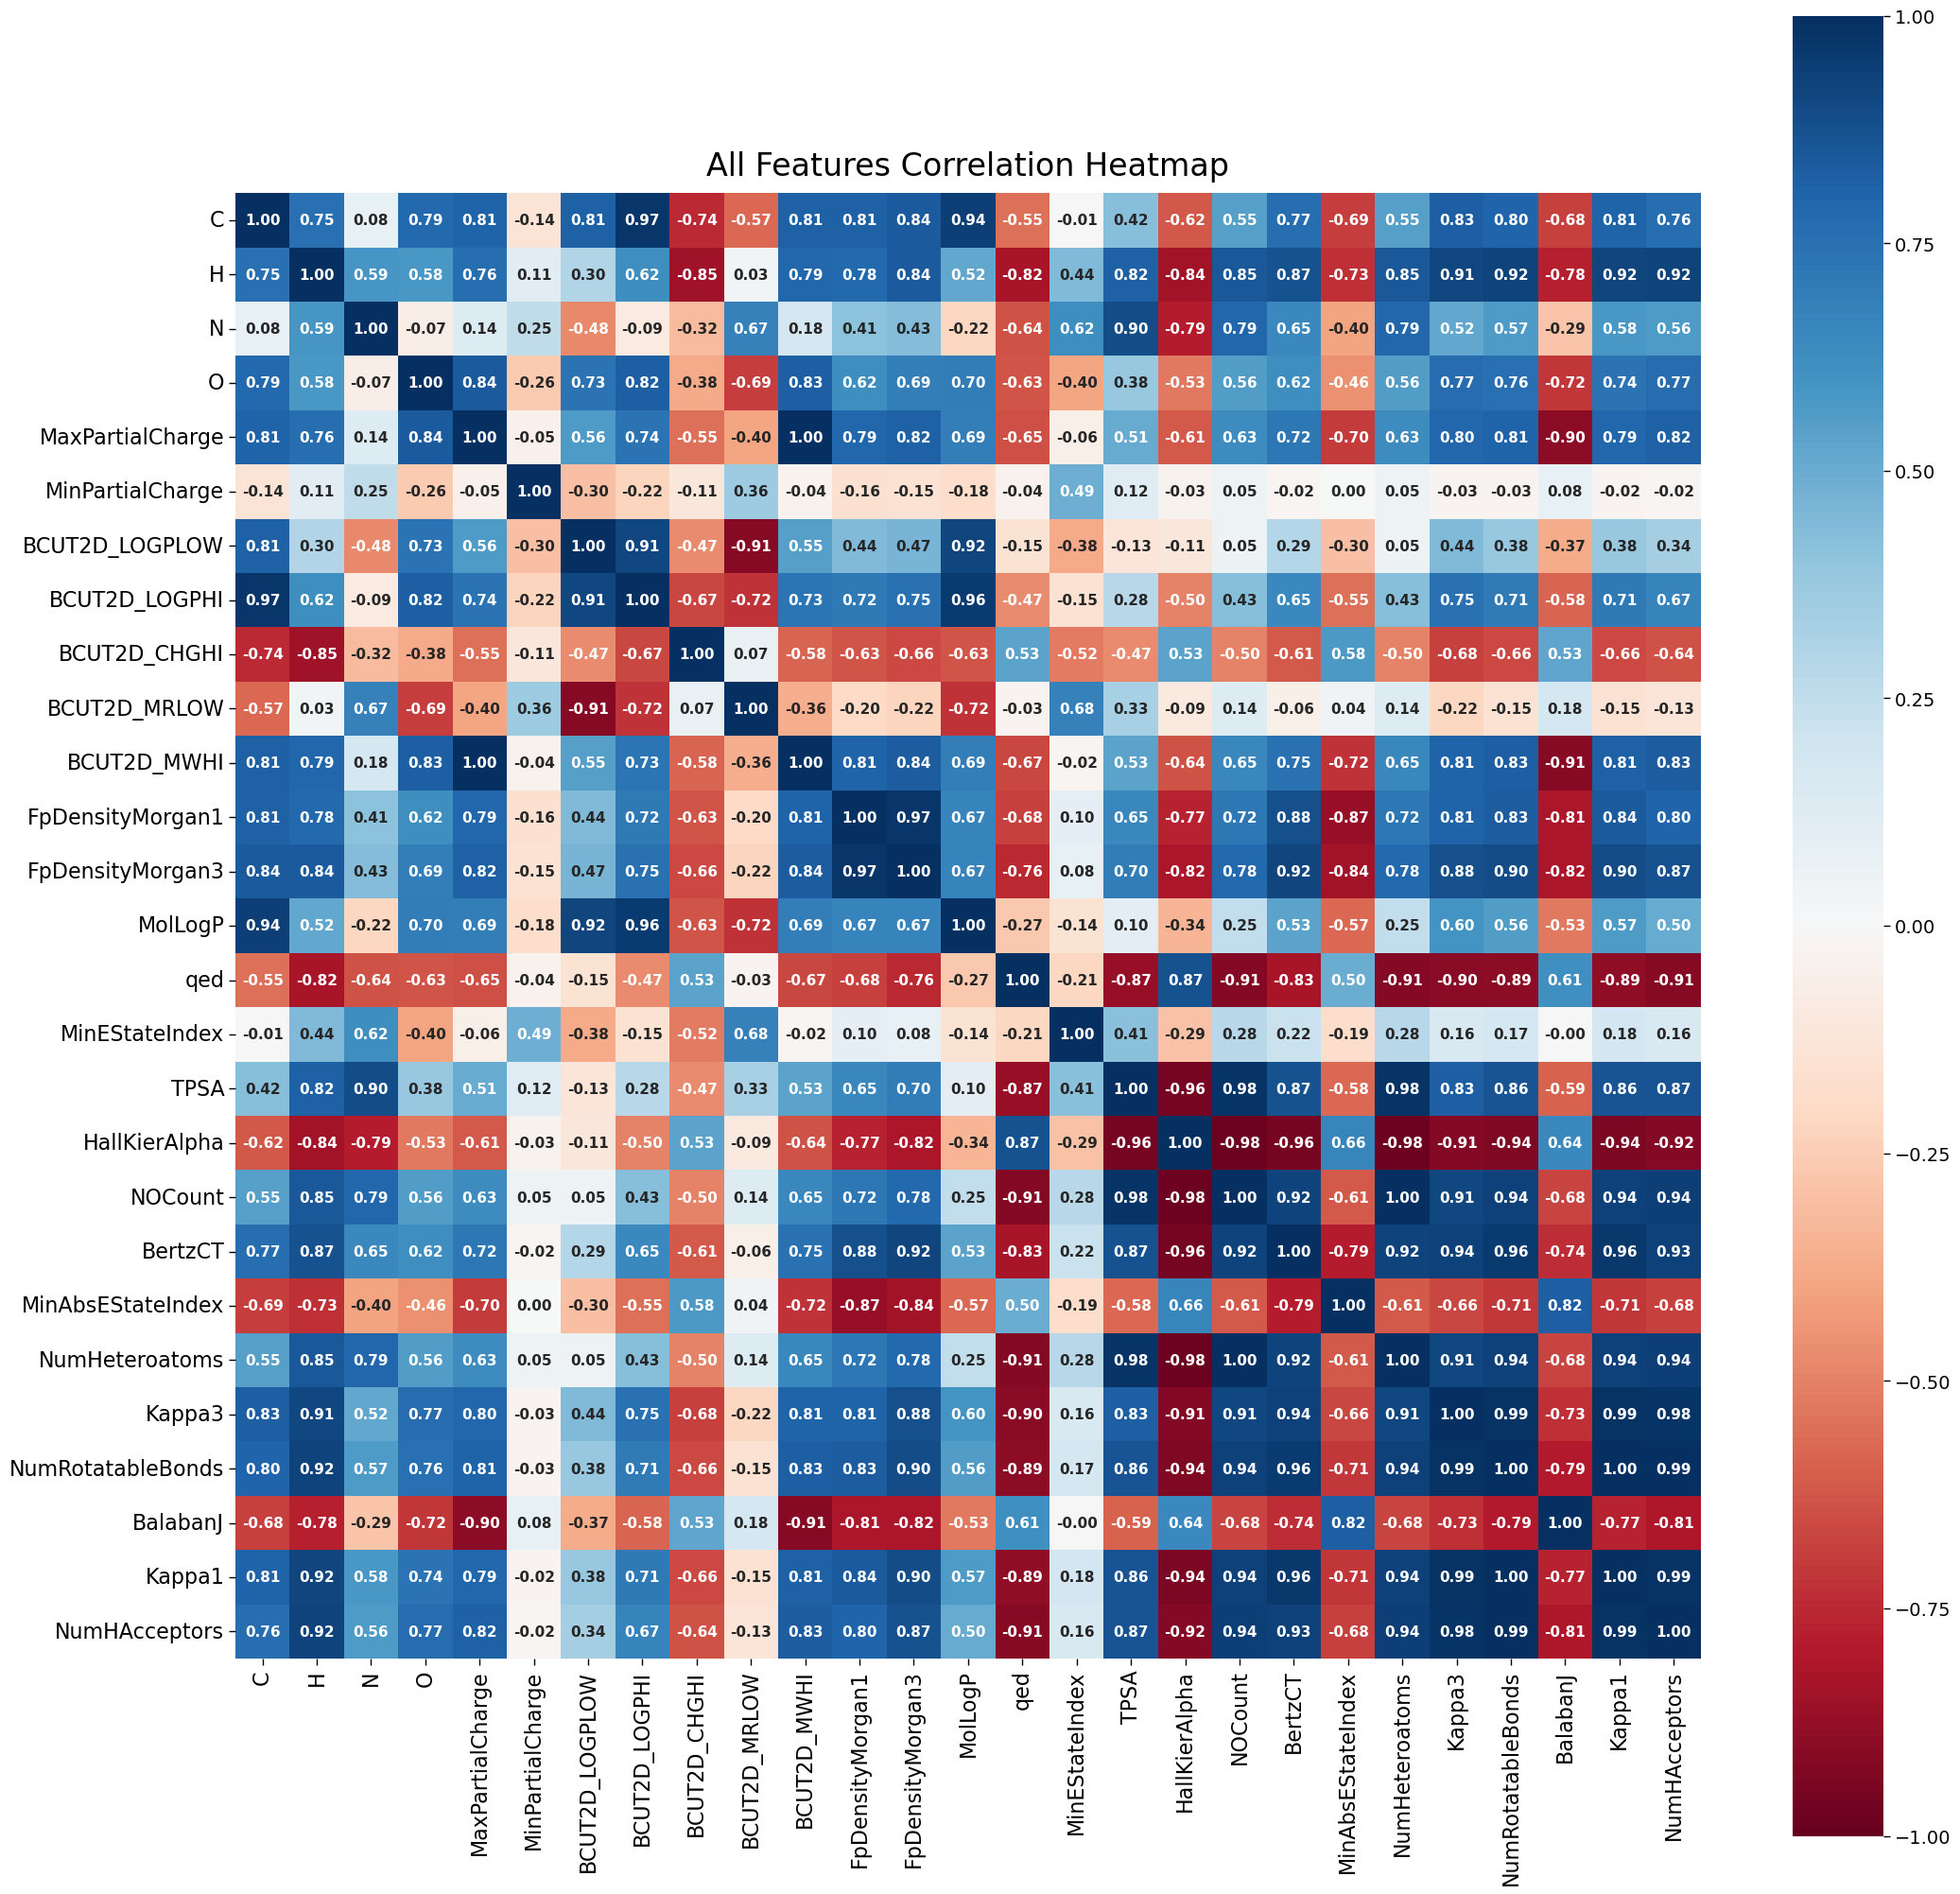

In [7]:
sns.set_context("paper", rc={"axes.labelsize":20})
fig, ax = plt.subplots(figsize=(25,25))  
heatmap = sns.heatmap(allfeaturedf.corr(), annot=True, annot_kws={'fontsize':11, 'fontweight':'bold'}, 
            cmap='RdBu', vmin=-1, vmax=1, square=True, fmt='0.2f', ax=ax)
heatmap.set_title('All Features Correlation Heatmap', fontdict={'fontsize':24}, pad=14);
heatmap.set_xticklabels(heatmap.get_xmajorticklabels(), fontsize = 16)
heatmap.set_yticklabels(heatmap.get_ymajorticklabels(), fontsize = 16)

cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)

plt.savefig('All_Feature_correlations_heatmap.png', dpi=1000, bbox_inches='tight')
plt.savefig('All_Feature_correlations_heatmap.jpg', dpi=1000,bbox_inches='tight')
plt.savefig('All_Feature_correlations_heatmap.svg',bbox_inches='tight')
plt.savefig('All_Feature_correlations_heatmap.pdf', bbox_inches='tight')
plt.savefig('All_Feature_correlations_heatmap.eps',bbox_inches='tight')

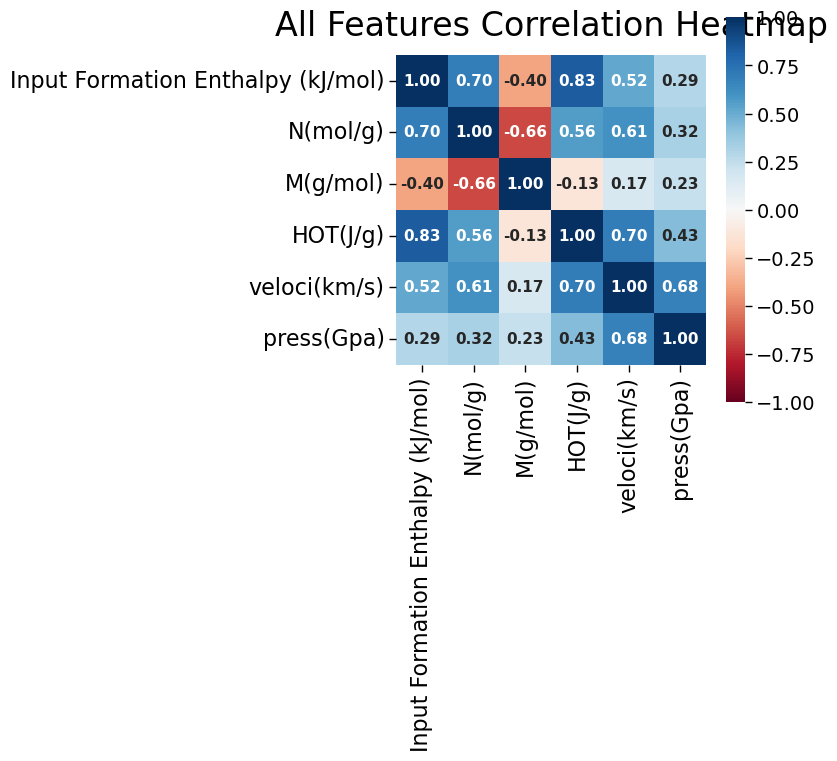

In [11]:
sns.set_context("paper", rc={"axes.labelsize":20})
fig, ax = plt.subplots(figsize=(5,5))  
heatmap = sns.heatmap(targets.corr(), annot=True, annot_kws={'fontsize':11, 'fontweight':'bold'}, 
            cmap='RdBu', vmin=-1, vmax=1, square=True, fmt='0.2f', ax=ax)
heatmap.set_title('All Features Correlation Heatmap', fontdict={'fontsize':24}, pad=14);
heatmap.set_xticklabels(heatmap.get_xmajorticklabels(), fontsize = 16)
heatmap.set_yticklabels(heatmap.get_ymajorticklabels(), fontsize = 16)

cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)

plt.savefig('All_Feature_correlations_heatmap.png', dpi=1000, bbox_inches='tight')
plt.savefig('All_Feature_correlations_heatmap.jpg', dpi=1000,bbox_inches='tight')
plt.savefig('All_Feature_correlations_heatmap.svg',bbox_inches='tight')
plt.savefig('All_Feature_correlations_heatmap.pdf', bbox_inches='tight')
plt.savefig('All_Feature_correlations_heatmap.eps',bbox_inches='tight')

In [12]:
import sklearn
print("scikit-learn version:", sklearn.__version__)


scikit-learn version: 1.6.1


In [43]:
from sklearn.decomposition import PCA

# Reduce to 10 principal components
pca = PCA(n_components=20)
X_reduced = pca.fit_transform(allfeaturedf)

print("Shape of original data:", allfeaturedf.shape)
print("Shape after PCA:", X_reduced.shape)
print("Explained variance ratio for 10 components:", pca.explained_variance_ratio_)
print("Cumulative variance captured:", pca.explained_variance_ratio_.cumsum()[-1])


Shape of original data: (112, 27)
Shape after PCA: (112, 20)
Explained variance ratio for 10 components: [9.89007669e-01 1.07922342e-02 1.53524971e-04 3.83317770e-05
 6.31863061e-06 1.61849828e-06 1.41446493e-07 1.10046762e-07
 2.98125638e-08 1.18361916e-08 4.11940962e-09 2.49435683e-09
 1.29127477e-09 1.02876680e-09 3.86127036e-10 6.38798321e-11
 4.68216359e-11 2.94180298e-11 7.22370634e-12 3.16226811e-12]
Cumulative variance captured: 0.9999999999993104


In [44]:
X_reduced


array([[ 3.07073180e+02, -2.33148354e+00,  3.01075435e+00, ...,
         8.70922817e-04,  1.32972878e-04,  3.90798683e-05],
       [ 1.22187613e+02,  1.02512629e+00,  1.17903738e+00, ...,
        -1.50451196e-03, -2.61323423e-04, -1.54377374e-04],
       [ 8.30029493e+00, -1.84876071e+01,  1.27137285e+00, ...,
        -1.20721875e-03, -3.90137173e-04,  1.96837372e-05],
       ...,
       [ 2.06100287e+02, -1.17487259e+01, -7.62846524e-01, ...,
         8.44034257e-04,  6.46855186e-04, -1.41079233e-04],
       [ 2.61024516e+02, -2.24994175e+01, -2.53986005e+00, ...,
        -9.28751475e-04, -1.29479356e-03,  4.53259220e-04],
       [ 2.06100353e+02, -1.17494233e+01, -7.60774347e-01, ...,
        -1.14500523e-03,  5.21502691e-04, -3.54560873e-04]])

In [45]:
import pandas as pd

pca_df = pd.DataFrame(X_reduced, columns=[f'PC{i+1}' for i in range(20)])
print(pca_df.head())


          PC1        PC2       PC3       PC4       PC5       PC6       PC7  \
0  307.073180  -2.331484  3.010754  0.099974  0.192786  0.208153 -0.145758   
1  122.187613   1.025126  1.179037 -0.856441 -0.052873 -0.171180  0.054922   
2    8.300295 -18.487607  1.271373 -0.605928 -0.404502 -0.121217  0.062477   
3  116.830033 -21.121975 -6.202346  0.431968  0.306459  0.141817 -0.059038   
4   10.480596 -12.928704  0.681014  0.695057 -0.498651 -0.122233 -0.004312   

        PC8       PC9      PC10      PC11      PC12      PC13      PC14  \
0  0.035245  0.023026  0.002916 -0.002910  0.005482  0.007291  0.001987   
1 -0.004778  0.012884  0.005248 -0.015247  0.000020 -0.002380 -0.000715   
2 -0.027240 -0.033567 -0.002458 -0.006982  0.006240  0.008534  0.002339   
3 -0.046444 -0.008710  0.036775  0.003950 -0.002566  0.005576 -0.004569   
4 -0.097610 -0.010888  0.002134 -0.002800  0.003060  0.006315  0.004142   

       PC15      PC16      PC17      PC18      PC19      PC20  
0 -0.001869  0.0

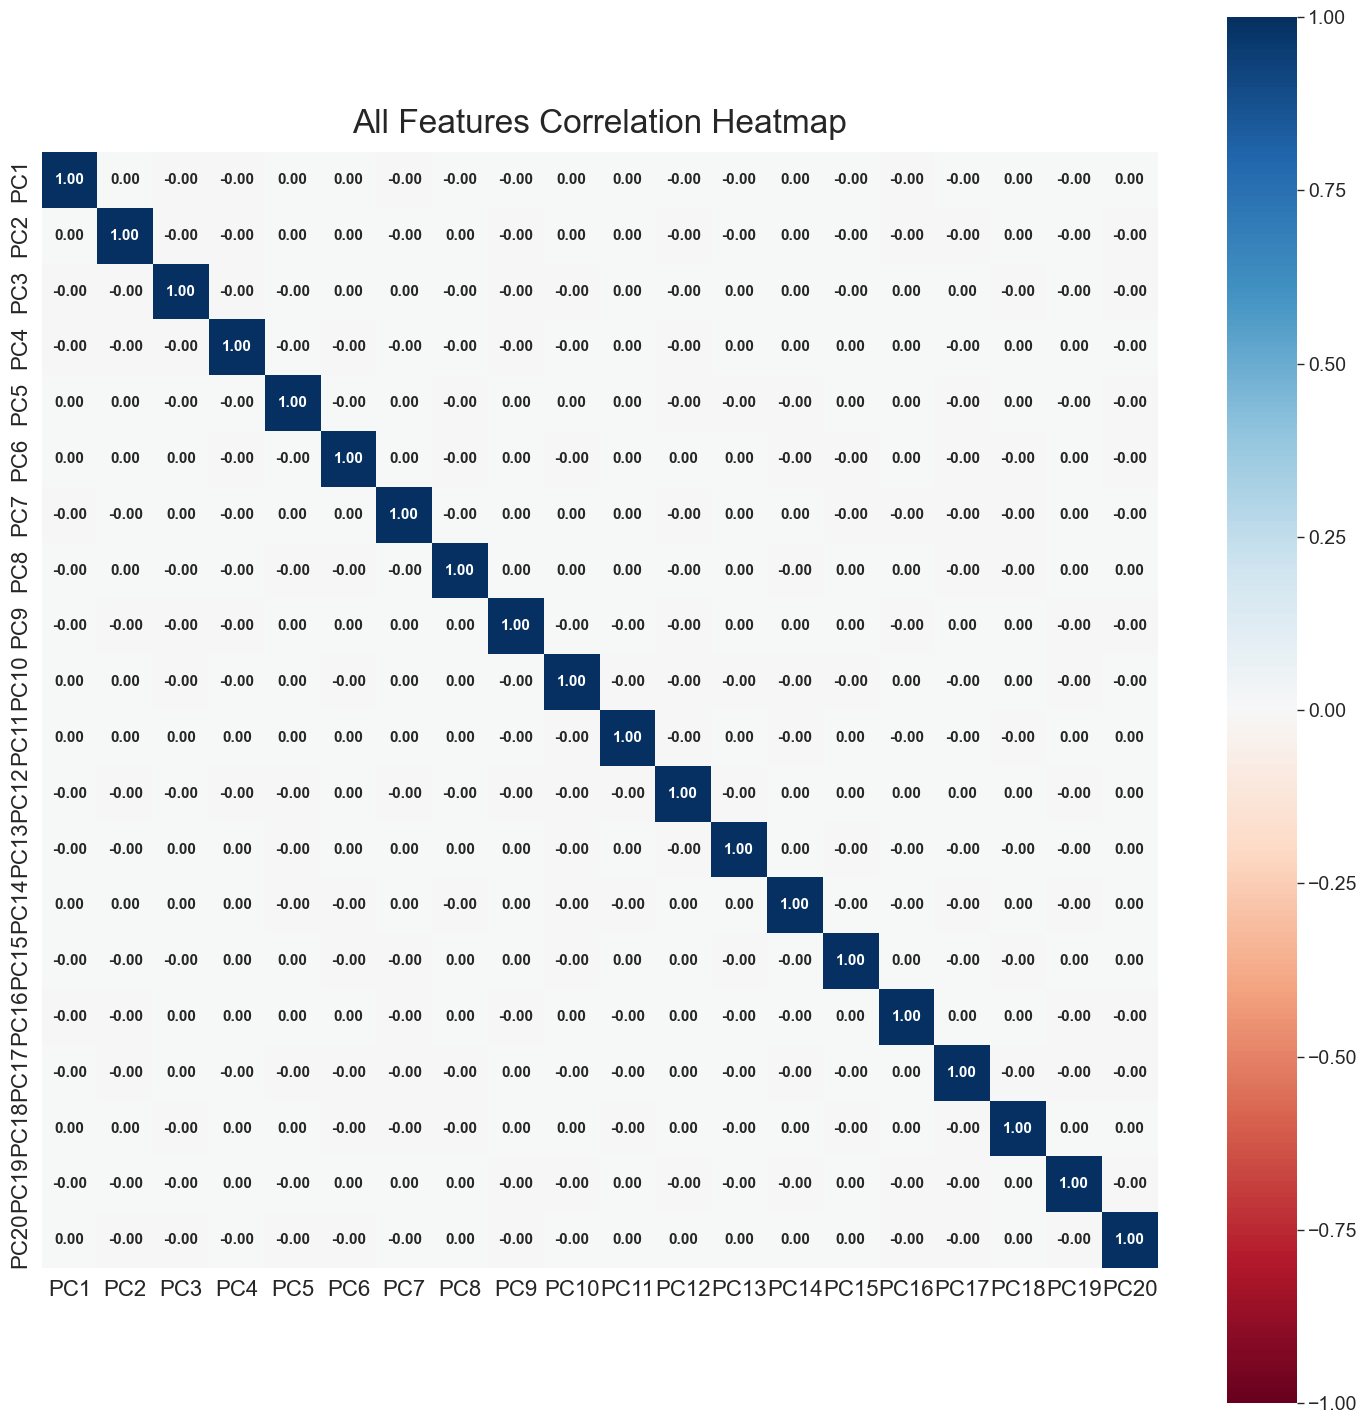

In [71]:
sns.set_context("paper", rc={"axes.labelsize":20})
fig, ax = plt.subplots(figsize=(18,18))  
heatmap = sns.heatmap(pca_df.corr(), annot=True, annot_kws={'fontsize':11, 'fontweight':'bold'}, 
            cmap='RdBu', vmin=-1, vmax=1, square=True, fmt='0.2f', ax=ax)
heatmap.set_title('All Features Correlation Heatmap', fontdict={'fontsize':24}, pad=14);
heatmap.set_xticklabels(heatmap.get_xmajorticklabels(), fontsize = 16)
heatmap.set_yticklabels(heatmap.get_ymajorticklabels(), fontsize = 16)

cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)

plt.savefig('All_Feature_correlations_heatmap.png', dpi=1000, bbox_inches='tight')
plt.savefig('All_Feature_correlations_heatmap.jpg', dpi=1000,bbox_inches='tight')
plt.savefig('All_Feature_correlations_heatmap.svg',bbox_inches='tight')
plt.savefig('All_Feature_correlations_heatmap.pdf', bbox_inches='tight')
plt.savefig('All_Feature_correlations_heatmap.eps',bbox_inches='tight')

In [48]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [50]:
# Example data
X = allfeaturedf  # shape (112, 27)
y = targets  # shape (112, 6)

In [52]:
# 1️⃣ Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [53]:
# 2️⃣ Feature scaling
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

In [54]:
# 3️⃣ Target scaling
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

In [55]:
# 4️⃣ PCA (optional, keep 5 components)
pca = PCA(n_components=5)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [56]:
# 5️⃣ Multi-output SVR
base_svr = SVR(kernel='rbf', C=1.0, epsilon=0.1)
multi_svr = MultiOutputRegressor(base_svr)
multi_svr.fit(X_train_pca, y_train_scaled)

MultiOutputRegressor(estimator=SVR())

In [63]:
# Prediction in scaled space
y_pred_scaled = multi_svr.predict(X_test_pca)  # or X_test_scaled if not using PCA

# Inverse transform to original target scale
y_pred = scaler_y.inverse_transform(y_pred_scaled)


In [65]:
# 8️⃣ Evaluate for each target
for i in range(y.shape[1]):
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred[:, i]))
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
    print(f"Target {i+1}: RMSE={rmse:.3f}, R²={r2:.3f}")

Target 1: RMSE=37.529, R²=0.991
Target 2: RMSE=0.000, R²=0.885
Target 3: RMSE=0.387, R²=0.826
Target 4: RMSE=245.058, R²=0.653
Target 5: RMSE=0.123, R²=0.874
Target 6: RMSE=0.688, R²=0.939


In [68]:
for i in range(y.shape[1]):
    actual = y_test.iloc[:, i]
    predicted = y_pred[:, i]
    print(f"Target {i+1} - actual dtype: {actual.dtype}, predicted dtype: {predicted.dtype}")


Target 1 - actual dtype: float64, predicted dtype: float64
Target 2 - actual dtype: object, predicted dtype: float64
Target 3 - actual dtype: object, predicted dtype: float64
Target 4 - actual dtype: object, predicted dtype: float64
Target 5 - actual dtype: object, predicted dtype: float64
Target 6 - actual dtype: object, predicted dtype: float64


In [69]:
for i in range(1, y.shape[1]):  # Skip target 1 since it's fine
    y_test.iloc[:, i] = pd.to_numeric(y_test.iloc[:, i], errors='coerce')


In [69]:
for i in range(1, y.shape[1]):  # Skip target 1 since it's fine
    y_test.iloc[:, i] = pd.to_numeric(y_test.iloc[:, i], errors='coerce')


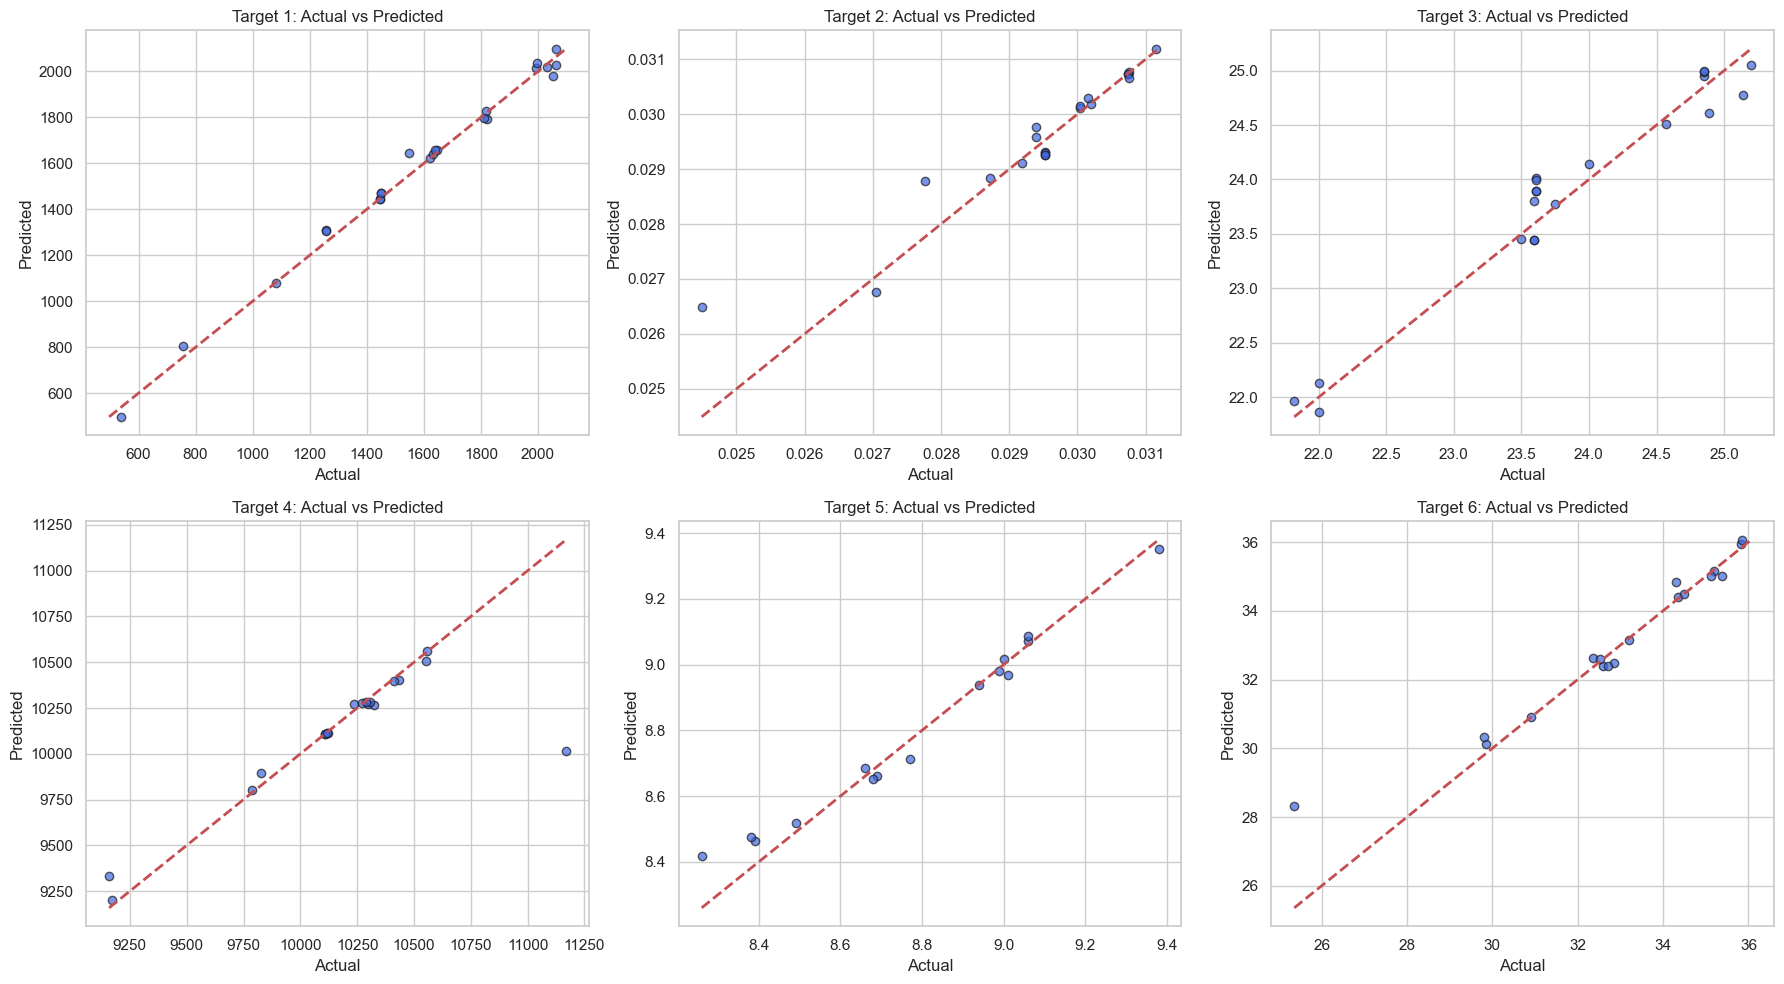

In [70]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i in range(y.shape[1]):
    ax = axes[i]
    actual = y_test.iloc[:, i]
    predicted = y_pred[:, i]
    
    # Remove NaNs
    mask = ~actual.isna() & ~pd.isna(predicted)
    actual = actual[mask]
    predicted = predicted[mask]
    
    ax.scatter(actual, predicted, alpha=0.7, color="royalblue", edgecolor='k')
    
    min_val = min(actual.min(), predicted.min())
    max_val = max(actual.max(), predicted.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.set_title(f"Target {i+1}: Actual vs Predicted")
    ax.grid(True)

plt.tight_layout()
plt.show()


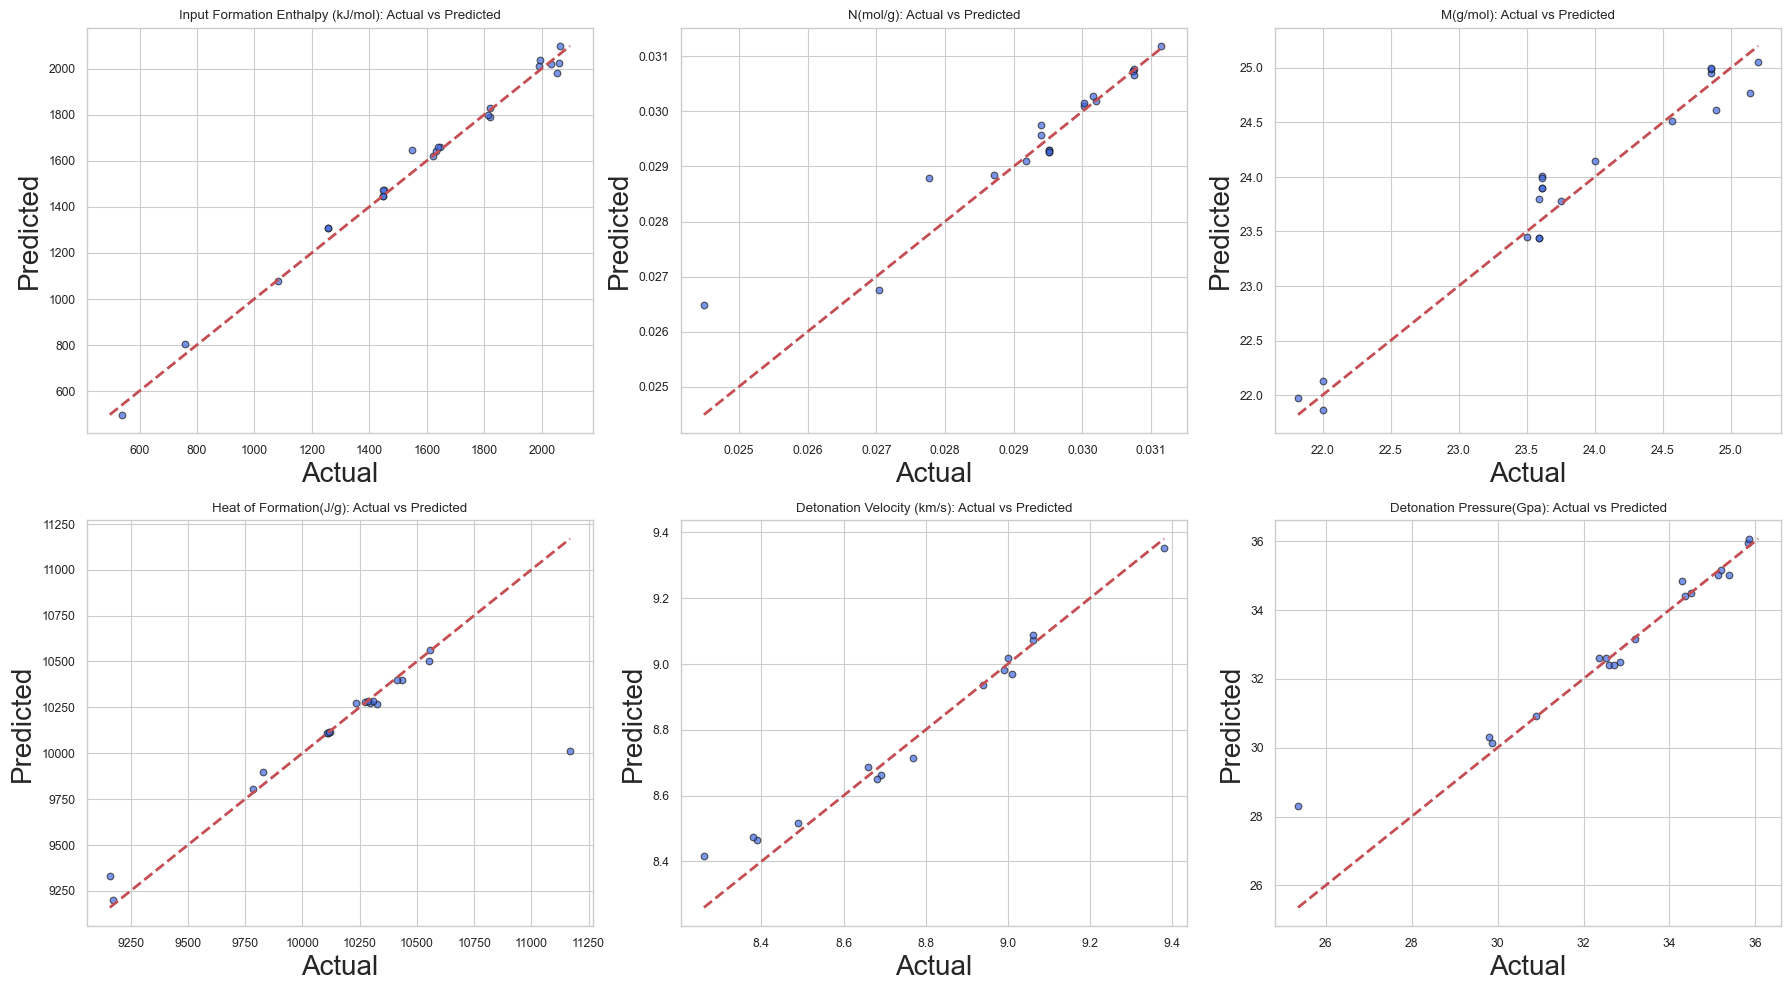

In [72]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Define your target names
target_names = [
    "Input Formation Enthalpy (kJ/mol)",
    "N(mol/g)",
    "M(g/mol)",
    "Heat of Formation(J/g)",
    "Detonation Velocity (km/s)",
    "Detonation Pressure(Gpa)"
]

for i in range(y.shape[1]):
    ax = axes[i]
    actual = y_test.iloc[:, i]
    predicted = y_pred[:, i]
    
    # Remove NaNs
    mask = ~actual.isna() & ~pd.isna(predicted)
    actual = actual[mask]
    predicted = predicted[mask]
    
    ax.scatter(actual, predicted, alpha=0.7, color="royalblue", edgecolor='k')
    
    min_val = min(actual.min(), predicted.min())
    max_val = max(actual.max(), predicted.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.set_title(f"{target_names[i]}: Actual vs Predicted")  # Use the custom names here
    ax.grid(True)

# Hide any unused subplots if you have fewer than 6 targets
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [75]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [76]:
# Example data
X = allfeaturedf  # shape (112, 27)
y = targets  # shape (112, 6)

In [77]:
# 1️⃣ Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [78]:
# 2️⃣ Feature scaling
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

In [79]:
# 3️⃣ Target scaling
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

In [80]:
# 4️⃣ PCA (optional, keep 5 components)
pca = PCA(n_components=15)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [81]:
# 5️⃣ Multi-output SVR
base_svr = SVR(kernel='rbf', C=1.0, epsilon=0.1)
multi_svr = MultiOutputRegressor(base_svr)
multi_svr.fit(X_train_pca, y_train_scaled)

MultiOutputRegressor(estimator=SVR())

In [82]:
# Prediction in scaled space
y_pred_scaled = multi_svr.predict(X_test_pca)  # or X_test_scaled if not using PCA

# Inverse transform to original target scale
y_pred = scaler_y.inverse_transform(y_pred_scaled)


In [83]:
# 8️⃣ Evaluate for each target
for i in range(y.shape[1]):
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred[:, i]))
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
    print(f"Target {i+1}: RMSE={rmse:.3f}, R²={r2:.3f}")

Target 1: RMSE=34.683, R²=0.993
Target 2: RMSE=0.000, R²=0.894
Target 3: RMSE=0.362, R²=0.848
Target 4: RMSE=237.757, R²=0.673
Target 5: RMSE=0.124, R²=0.871
Target 6: RMSE=0.675, R²=0.941


In [84]:
for i in range(y.shape[1]):
    actual = y_test.iloc[:, i]
    predicted = y_pred[:, i]
    print(f"Target {i+1} - actual dtype: {actual.dtype}, predicted dtype: {predicted.dtype}")


Target 1 - actual dtype: float64, predicted dtype: float64
Target 2 - actual dtype: object, predicted dtype: float64
Target 3 - actual dtype: object, predicted dtype: float64
Target 4 - actual dtype: object, predicted dtype: float64
Target 5 - actual dtype: object, predicted dtype: float64
Target 6 - actual dtype: object, predicted dtype: float64


In [85]:
for i in range(1, y.shape[1]):  # Skip target 1 since it's fine
    y_test.iloc[:, i] = pd.to_numeric(y_test.iloc[:, i], errors='coerce')


In [86]:
for i in range(1, y.shape[1]):  # Skip target 1 since it's fine
    y_test.iloc[:, i] = pd.to_numeric(y_test.iloc[:, i], errors='coerce')


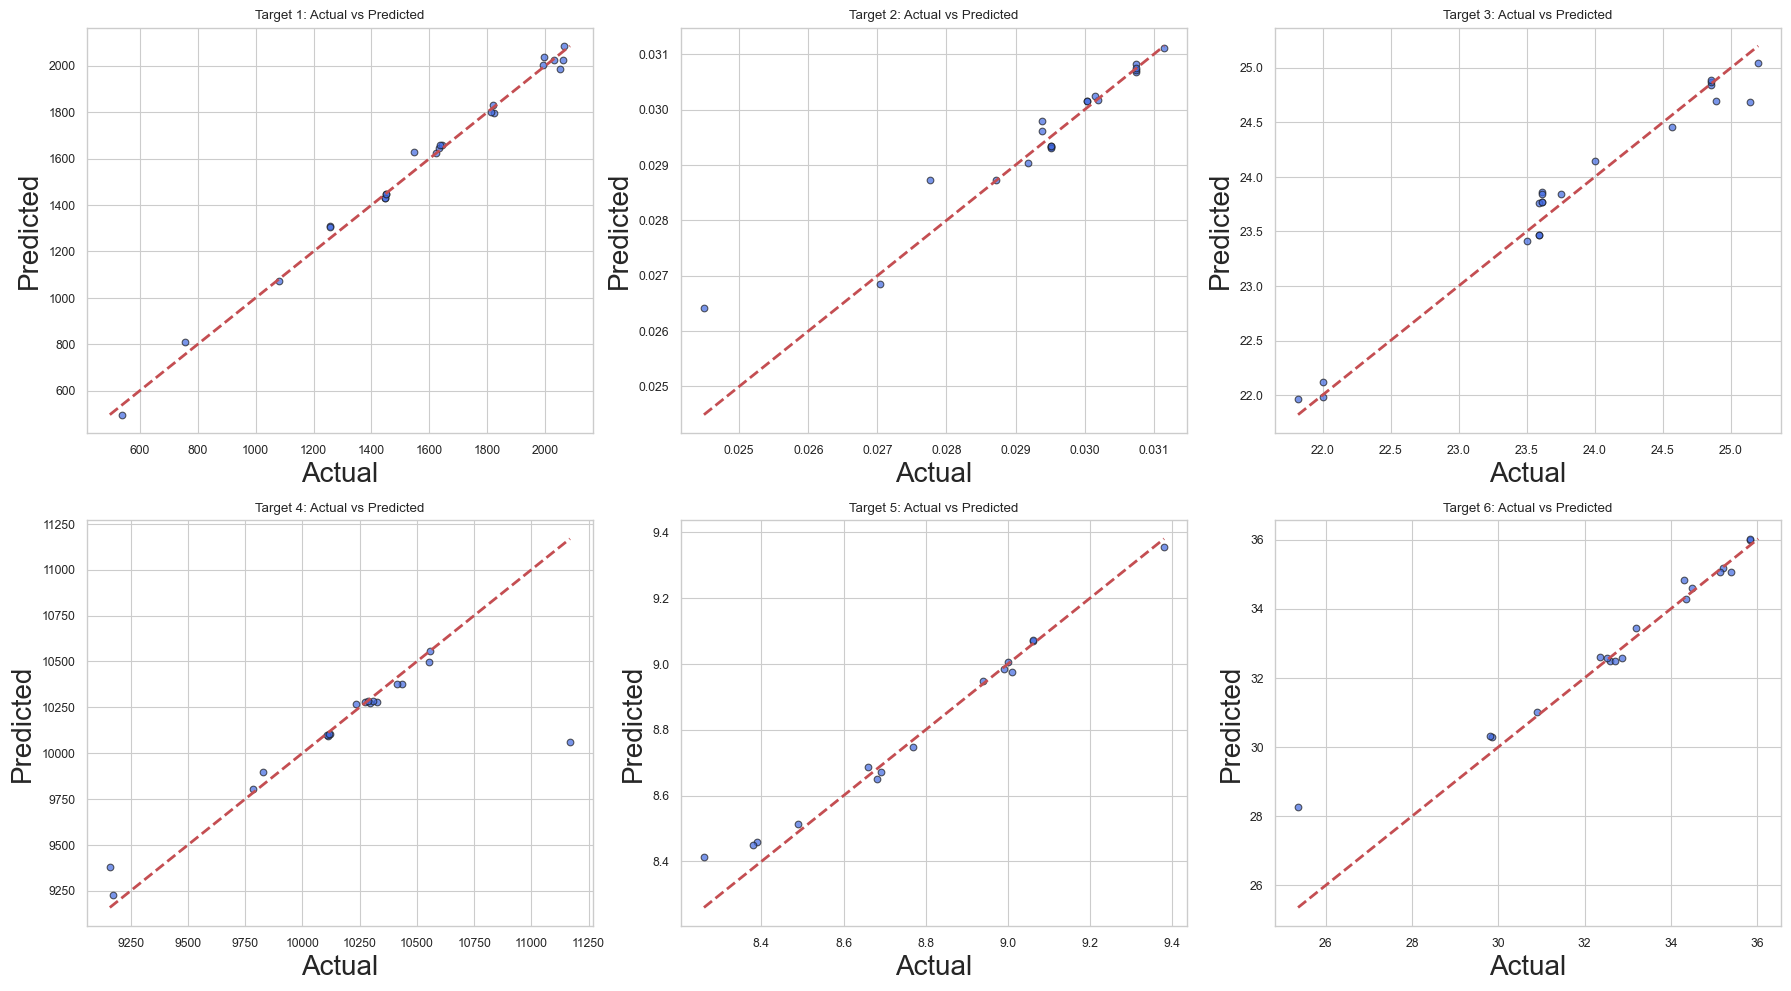

In [87]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i in range(y.shape[1]):
    ax = axes[i]
    actual = y_test.iloc[:, i]
    predicted = y_pred[:, i]
    
    # Remove NaNs
    mask = ~actual.isna() & ~pd.isna(predicted)
    actual = actual[mask]
    predicted = predicted[mask]
    
    ax.scatter(actual, predicted, alpha=0.7, color="royalblue", edgecolor='k')
    
    min_val = min(actual.min(), predicted.min())
    max_val = max(actual.max(), predicted.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.set_title(f"Target {i+1}: Actual vs Predicted")
    ax.grid(True)

plt.tight_layout()
plt.show()
